<a href="https://colab.research.google.com/github/JhoelVillca/svm-mantenimiento-predictivo/blob/main/Mantenimiento_Predictivo_SVM_JhoelVillca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mantenimiento Predictivo mediante Maquinas de Soporte Vectorial (SVM)
**Desarrollado por:** Jhoel Mauricio Villca Villca  
**Carrera:** Ingenieria de Sistemas  

## 1. Consolidacion de Dependencias e Importaciones
En esta seccion se cargan todas las librerias necesarias para el ciclo completo del proyecto: manipulacion de datos, procesamiento estadistico, aprendizaje automatico y visualizacion de datos. Centralizar las importaciones al inicio es una buena practica de desarrollo que evita la redundancia y optimiza el uso de memoria en el entorno de ejecucion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

## 2. Limpieza de datos (Data Cleaning)
En esta fase introducimos el dataset de telemetria al sistema. Para garantizar la integridad del modelo predictivo, se realiza una purga de variables. Eliminamos identificadores unicos que no tienen peso matematico (como UDI o Product ID) y descartamos las columnas de subcategorias de fallos (TWF, HDF, etc.). Si el algoritmo viera estas ultimas, sufriria de *Data Leakage* (fuga de datos), es decir, haria trampa aprendiendo la respuesta antes de predecir la variable objetivo `Machine failure`. y tambien renombramos las columnas para evitar espacios y caracteres conflictivos.

In [3]:
ruta_archivo = 'telemetria_hardware.csv'
df = pd.read_csv(ruta_archivo)

In [4]:
columnas_basura = ['UDI', 'Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=columnas_basura)

In [5]:
df_clean.columns = ['Temp_Aire_K', 'Temp_Proceso_K', 'RPM', 'Torque_Nm', 'Desgaste_min', 'Fallo']

In [6]:
df_clean.head()

,Temp_Aire_K,Temp_Proceso_K,RPM,Torque_Nm,Desgaste_min,Fallo
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


## 3. Analisis Exploratorio: Distribucion del Estado de Hardware
Antes de entrenar la maquina, necesitamos conocer el terreno por asi decirlo. En este grafico veremos que la gran mayoria de los servidores estan sanos (0) y solo una pequeña fraccion presenta fallos (1). Esto es normal en la infraestructura real, pero nos obligara a configurar el modelo mas adelante para que no ignore a estos

/tmp/ipykernel_42257/3449195276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Fallo', data=df_clean, palette=['#3498db', '#e74c3c'])


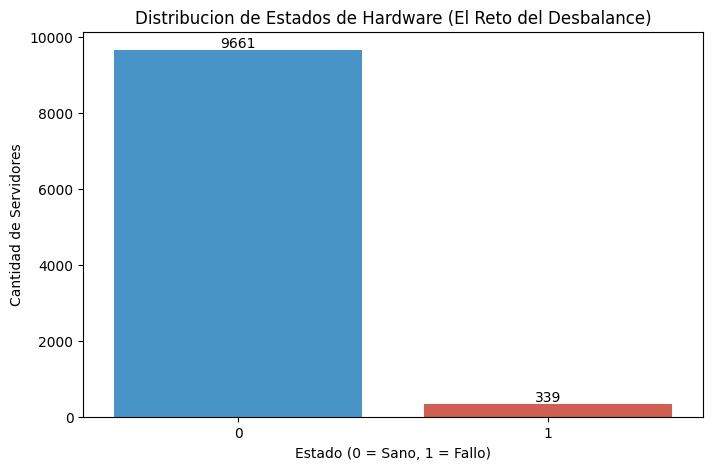

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Fallo', data=df_clean, palette=['#3498db', '#e74c3c'])
plt.title('Distribucion de Estados de Hardware (El Reto del Desbalance)')
plt.xlabel('Estado (0 = Sano, 1 = Fallo)')
plt.ylabel('Cantidad de Servidores')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

## 4. Analisis Exploratorio: Matriz de Correlacion de Sensores
Aqui aplicamos una matriz de correlacion lineal de Pearson. En terminos simples, esto nos muestra como interactuan los sensores entre si. Si el valor se acerca a 1 o -1, es decir que cuando una variable sube, la otra reacciona. Esto le ayuda al algoritmo a entender que la temperatura y el torque no son variables aisladas, sino que forman parte de un ecosistema mecanico entrelazado.

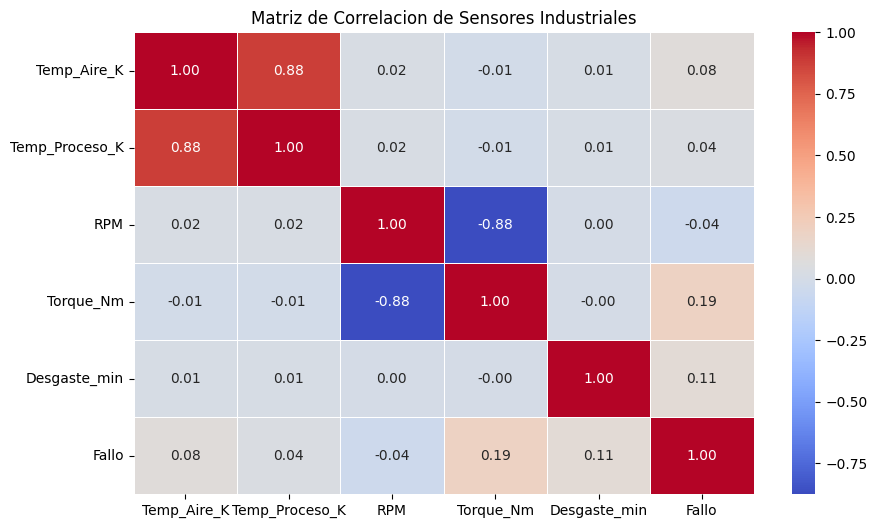

In [8]:
plt.figure(figsize=(10, 6))
correlacion = df_clean.corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlacion de Sensores Industriales')
plt.show()

## 5. Separacion y Estandarizacion de Vectores (Preprocesamiento)
En esta etapa preparamos los datos para el calculo matematico. Primero, dividimos el dataset: 80% para entrenar la maquina y 20% para ponerlo a pruba. Usamos una particion estratificada (`stratify`) para asegurar que la proporcion de fallos sea equitativa en ambos lados.

Luego, aplicaremos la estandarizacion. Las temperaturas y las revoluciones por minuto (RPM) manejan escalas muy distintas (cientos vs miles). La estandarizacion ajusta todos estos valores a una misma regla de medicion proporcional, evitando que el motor SVM le de mas importancia a una variable solo porque su numero crudo es mas grande.

In [9]:
X = df_clean.drop('Fallo', axis=1)
y = df_clean['Fallo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:3]

array([[ 0.99891359,  0.60428162, -0.46060741,  0.71830476, -0.84399726],
       [-1.50519408, -1.15325984, -0.77557391,  0.63845583,  0.38226308],
       [ 0.49809206,  1.07746586, -1.00765448,  0.5586069 ,  0.46086951]])

## 6. El Nucleo Matematico: Entrenamiento del Modelo SVM
Ahora vamos a encender el motor predictivo. Entrenaremos el clasificador de Maquinas de Vectores de Soporte (SVM). Dado que las fallas mecanicas no se pueden separar con una linea recta simple en el mundo real, aplicamos un Kernel RBF (Radial Basis Function) para que este mecanismo proyecte los datos a un espacio de multiples dimensiones donde si es posible trazar una frontera plana. La definicion matematica general de ese hiperplano es: $$w \cdot x + b = 0$$

Ademas, usamos el parametro `class_weight='balanced'`. Como en infraestructura las caidas de servidor son menos, este parametro penaliza al algoritmo si pasa por alto un fallo, asi para forzar a priorizar la seguridad del hardware.

In [10]:
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_model

SVC(class_weight='balanced', random_state=42)

## 7. Evaluacion del Sistema: Reporte de Rendimiento
Con el modelo entrenado, realizamos la prueba usando el 20% de los datos que aislamos al principio (`X_test_scaled`). Para mantener una presentacion ejecutiva, transformamos el reporte de clasificacion tradicional en un DataFrame. y aqui evaluamos las metricas clave como la precision (efectividad al evitar falsas alarmas) y el recall (capacidad de capturar los fallos reales antes de que ocurran).

In [11]:
y_pred = svm_model.predict(X_test_scaled)
reporte = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(reporte).transpose()

,precision,recall,f1-score,support
0,0.997172,0.912526,0.952973,1932.000
1,0.271552,0.926471,0.420000,68.000
accuracy,0.913000,0.913000,0.913000,0.913
macro avg,0.634362,0.919498,0.686486,2000.000
weighted avg,0.972501,0.913000,0.934852,2000.000


## 8. Analisis de Errores: Matriz de Confusion Visual
Para entender exactamente en que se esta equivocando la maquina, podemos graficar la Matriz de Confusion mediante un mapa de calor. Los cuadrantes principales nos muestran los aciertos: Verdaderos Negativos (equipos sanos confirmados) y Verdaderos Positivos (fallos interceptados). Los cuadrantes cruzados revelan nuestros riesgos operativos: Falsos Positivos (alertas de mantenimiento innecesarias) y Falsos Negativos (el peor escenario: fallos ocultos que el sistema no vio venir).

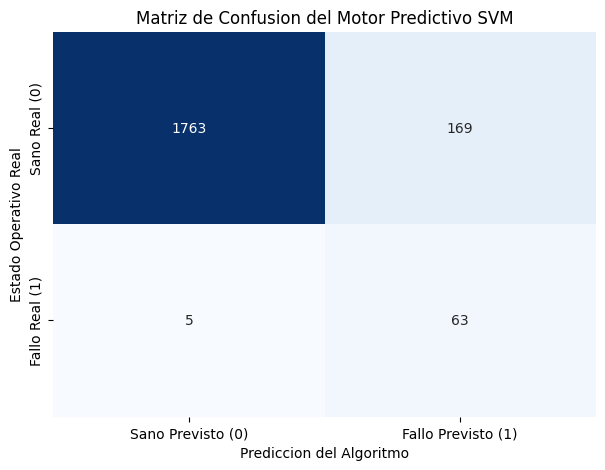

In [12]:
matriz_conf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sano Previsto (0)', 'Fallo Previsto (1)'],
            yticklabels=['Sano Real (0)', 'Fallo Real (1)'])
plt.title('Matriz de Confusion del Motor Predictivo SVM')
plt.ylabel('Estado Operativo Real')
plt.xlabel('Prediccion del Algoritmo')
plt.show()

## 9. Demostracion
aqui demostramos que el modelo es una herramienta operativa y no solo estadistica. Creamos una funcion que simula la entrada de telemetria en tiempo real. Esta funcion toma los datos crudos, los estandariza usando exactamente el mismo `scaler` del entrenamiento (paso vital para mantener la coherencia matematica y evitar desviaciones), y los cruza por el hiperplano del SVM para emitir un diagnostico automatizado.

In [13]:
def predecir_estado_servidor(temp_aire, temp_proceso, rpm, torque, desgaste):
    nombres_columnas = ['Temp_Aire_K', 'Temp_Proceso_K', 'RPM', 'Torque_Nm', 'Desgaste_min']
    datos_nuevos = pd.DataFrame([[temp_aire, temp_proceso, rpm, torque, desgaste]], columns=nombres_columnas)

    datos_escalados = scaler.transform(datos_nuevos)
    prediccion = svm_model.predict(datos_escalados)

    estado = "FALLO INMINENTE - Aislar nodo" if prediccion[0] == 1 else "OK - Rango seguro"

    resultado = pd.DataFrame({
        'Temp_Aire_K': [temp_aire],
        'Temp_Proceso_K': [temp_proceso],
        'RPM': [rpm],
        'Torque_Nm': [torque],
        'Desgaste_min': [desgaste],
        'DIAGNOSTICO_SVM': [estado]
    })
    return resultado

## 10. Pruebas de Simulacion
Ejecutamos dos escenarios cruzados. La "Prueba 1" introduce telemetria de un equipo operando con carga estandar. La "Prueba 2" inyecta anomalias fisicas evidentes (alto desgaste, bajas revoluciones y exceso de torque). El modelo procesa ambas y tambien imprime el diagnostico operativo.

In [14]:
prueba_1 = predecir_estado_servidor(298.1, 308.6, 1551, 42.8, 10)
prueba_2 = predecir_estado_servidor(302.5, 311.2, 1300, 65.5, 220)

pd.concat([prueba_1, prueba_2], keys=['Nodo A (Normal)', 'Nodo B (Anomalia)'])

,,Temp_Aire_K,Temp_Proceso_K,RPM,Torque_Nm,Desgaste_min,DIAGNOSTICO_SVM
Nodo A (Normal),0,298.1,308.6,1551,42.8,10,OK - Rango seguro
Nodo B (Anomalia),0,302.5,311.2,1300,65.5,220,FALLO INMINENTE - Aislar nodo


## 11. Representacion del Hiperplano SVM (Proyeccion 2D)
Nuestro modelo real procesa 5 variables continuas, lo que significa que el hiperplano separador existe en 5 dimensiones lo que es mas dificil graficar, asi que aislamos dos variables mecanicas de alta correlacion (RPM y Torque) y entrenamos un modelo visual pedagogico con la misma logica.

La grafica proyecta la superficie de decision generada por el Kernel RBF. Observamos como el algoritmo traza fronteras curvas complejas para encapsular la "zona de fallos" (area roja) y separarla de la "zona segura" (area azul), demostrando como el SVM resuelve problemas que no son linealmente separables.

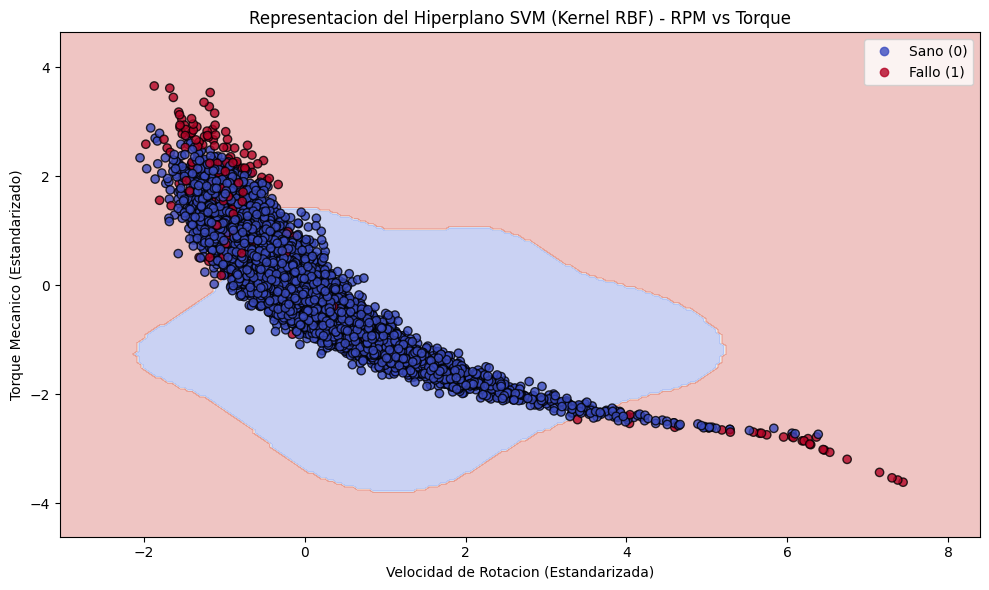

In [15]:
X_2d = X_train_scaled[:, 2:4]
y_2d = y_train

modelo_visual = SVC(kernel='rbf', class_weight='balanced', random_state=42)
modelo_visual.fit(X_2d, y_2d)

h = .05
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = modelo_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.8)

plt.title('Representacion del Hiperplano SVM (Kernel RBF) - RPM vs Torque')
plt.xlabel('Velocidad de Rotacion (Estandarizada)')
plt.ylabel('Torque Mecanico (Estandarizado)')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Sano (0)', 'Fallo (1)'], loc='upper right')

plt.tight_layout()
plt.show()